# Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms,datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Data Preprocessing

In [ ]:
transform=transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

In [ ]:
dataset =torchvision.datasets.OxfordIIITPet(
    root="./data",download=True,transform=transform
)

100%|██████████| 792M/792M [00:36<00:00, 22.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.5MB/s]


# Convert Dataset Into cats and dogs

In [ ]:
class BinaryPetDataset(torch.utils.data.Dataset):
  def __init__(self,dataset):
    self.dataset=dataset
  def __len__(self):
    return len(self.dataset)
  def __getitem__(self,idx):
    image,label=self.dataset[idx]

    if(label<12):
      label=0 #cat
    else:
      label=1 #dog
    return image,label
binary_dataset=BinaryPetDataset(dataset)

# Train_test_split

In [ ]:
from torch.utils.data import random_split
train_size=int(0.8*len(binary_dataset))
test_size=len(binary_dataset) - train_size
train_dataset,test_dataset=random_split(
    binary_dataset,[train_size,test_size]
)

# Create DataLoader

In [ ]:
trainLoader=DataLoader(train_dataset,batch_size=32,shuffle=True)
testLoader=DataLoader(test_dataset,batch_size=32)

# CNN Model

In [ ]:
class CNN(nn.Module):
  def __init__(self):
    super(CNN,self).__init__()
    self.conv_layers=nn.Sequential(
        nn.Conv2d(3,32,3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(32,64,3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2),

        nn.Conv2d(64,128,3,padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2,2)
    )
    self.fc_layers=nn.Sequential(
        nn.Linear(128*16*16,256),
        nn.ReLU(),
        nn.Linear(256,2)
    )
  def forward(self,x):
    x=self.conv_layers(x)
    x=x.view(x.size(0),-1)
    x=self.fc_layers(x)
    return x

# Model Initialize

In [ ]:
model=CNN()
criterion=nn.CrossEntropyLoss()
optimiser=optim.Adam(model.parameters(),lr=0.001)

# Training Loop

In [ ]:
epochs=10
train_losses=[]
for epoch in range(epochs):
  training_loss=0.0
  for image,label in trainLoader:
    optimiser.zero_grad()
    output=model(image)
    loss=criterion(output,label)
    loss.backward()
    optimiser.step()
    training_loss+=loss.item()
  avg_loss=training_loss/len(trainLoader)
  train_losses.append(avg_loss)
  print(f"Epoch {epoch+1}/{epochs},Loss : {avg_loss}")

Epoch 1/10,Loss : 0.645480860510598
Epoch 2/10,Loss : 0.6289846544032511
Epoch 3/10,Loss : 0.62677793658298
Epoch 4/10,Loss : 0.6158527245988017
Epoch 5/10,Loss : 0.5929087753529134
Epoch 6/10,Loss : 0.5528284288618875
Epoch 7/10,Loss : 0.5019435474406118
Epoch 8/10,Loss : 0.4136618500494439
Epoch 9/10,Loss : 0.26336336152061174
Epoch 10/10,Loss : 0.1354836316212364


# Plot Training Loss

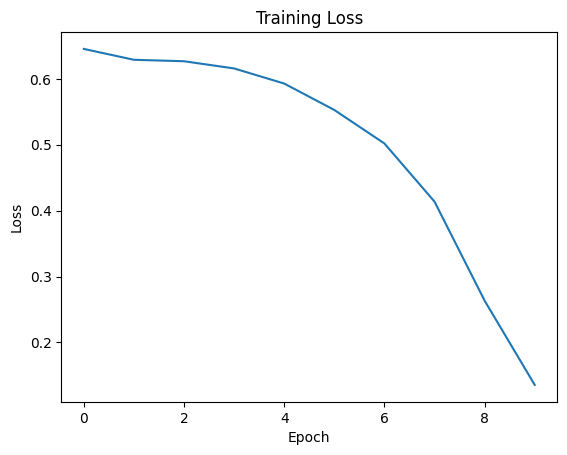

In [ ]:
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
correctLabels=0
totalLabels=0
model.eval()
with torch.no_grad():
  for image,label in testLoader:
    output=model(image)
    _,predicted=torch.max(output,1)
    correctLabels+=(predicted==label).sum().item()
    totalLabels+=label.size(0)
accuracy=correctLabels/totalLabels
print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 61.41%
